# Assignment 1 -- ML4F 2023

## Instructions
* This assignment covers the material discussed in Lectures ML1 - ML4. 
* Each group submits _only one_ notebook via canvas on the assignment page. 
* The notebook should be named `assignment1_groupXX.ipynb` where `XX` is your group number,  
e.g. for group 3 this will be `assignment1_group03.ipynb`.
* The notebook should run without raising any errors. 
* We recommend keeping the folder structure
```
assignment/
    data/
    lib/
    assignment1_groupXX.ipynb
```
* We strongly recommend git, as you are encouraged to collaborate and split up the work and maybe even start independently. To see how to set up your own repo for your group, see `VU Workshop Introduction to Version Control with GIT.pptx` discussed in week 2.
* Do not spend time on optimizing the speed of your code. However, if it runs for more than 5 minutes, we will terminate it.
* We strongly encourage you to experiment, try different approaches and combinations and get to know the problem from alternative angles. But the final notebook should only contain the necessary results for grading.
----

<div style="font-size:24px; text-align:center; font-weight:bold">Good luck!</div>

----

# Assignment 1 - Features & Algorithms

Kiwibank, a commercial bank from New Zealand, is interested in updating their loan default prediction algorithm. They used to check each client manually, and now they want to use Machine Learning to predict who will default on their loan and pose a threat to the bank's balance sheet. They have supplied you with a dataset of their past clients, and they've asked you to consult them on their adaptation of Machine Learning in this process.

First take a look at the data, then test different algorithms, select key features and write a recommendation to the bank.

State your imports below.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore", UserWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import ElasticNet

# Preprocessing (15 points)
*5 points for correct code*

*10 points for normalization procedure*

The data consists of 34 features and one target variable, 'Loan Status'
We have 25 numerical features and 9 categorical features. For the numerical features, apply a technique
to make the data more normal. This can be Standardization, Normalization, log or a Box-Cox transformation. 
Explain why you might use one method for some features, and another for other features.
Also check for missing values and uninformative features (NO FEATURE SELECTION YET).

In [2]:
df = pd.read_csv('8_ML4F_Assignment1Data.csv')
Y = df.pop("Loan Status")
df.dtypes
df = df.drop('Accounts Delinquent', axis = 'columns')

In [3]:
df.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,...,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit
0,0,17724354,15865,16843,10678.796150,59,BAT1780517,12.495408,A,A1,...,320.406948,0.034189,5.142861,0.164592,0,INDIVIDUAL,50,44,48547,6700
1,1,7817586,26452,4620,14767.939270,58,BAT1761981,14.811694,B,F2,...,1171.450361,0.069027,10.185495,0.298919,0,INDIVIDUAL,14,44,304244,9240
2,2,5125246,11679,33109,14174.843310,58,BAT2252229,18.772025,A,C4,...,2266.071626,0.047353,3.357589,1.377348,0,INDIVIDUAL,65,26,181143,2948
3,3,14645813,16510,6799,7157.243974,58,BAT2575549,15.278209,A,B3,...,530.529564,0.131287,8.310684,0.552169,0,INDIVIDUAL,148,50,195176,17582
4,4,4305490,33384,12909,6423.856119,58,BAT5849876,11.181638,E,B1,...,2627.877286,0.004037,3.011995,1.323489,0,INDIVIDUAL,113,46,136552,7745


In [4]:
df_numeric = pd.DataFrame()
for i, j in df.iteritems():
    if df[i].dtypes == 'int64' or df[i].dtypes == 'float64':
        n = 0
        df_numeric.insert(n,i,j)
        n+= 1
    else:
        continue
        
df_numeric.head()

C:\Users\Petko\AppData\Local\Temp\ipykernel_14092\2914825055.py:2: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for i, j in df.iteritems():


,Total Revolving Credit Limit,Total Current Balance,Total Collection Amount,Last week Pay,Collection 12 months Medical,Collection Recovery Fee,Recoveries,Total Received Late Fee,Total Received Interest,Total Accounts,...,Delinquency - two years,Debit to Income,Home Ownership,Interest Rate,Term,Funded Amount Investor,Funded Amount,Loan Amount,ID,Unnamed: 0
0,6700,48547,44,50,0,0.164592,5.142861,0.034189,320.406948,14,...,0,11.759703,128249.54510,12.495408,59,10678.796150,16843,15865,17724354,0
1,9240,304244,44,14,0,0.298919,10.185495,0.069027,1171.450361,14,...,0,26.115829,161382.83350,14.811694,58,14767.939270,4620,26452,7817586,1
2,2948,181143,26,65,0,1.377348,3.357589,0.047353,2266.071626,25,...,1,16.762895,150823.50770,18.772025,58,14174.843310,33109,11679,5125246,2
3,17582,195176,50,148,0,0.552169,8.310684,0.131287,530.529564,24,...,0,30.188378,138921.01180,15.278209,58,7157.243974,6799,16510,14645813,3
4,7745,136552,46,113,0,1.323489,3.011995,0.004037,2627.877286,19,...,0,36.624780,54727.95182,11.181638,58,6423.856119,12909,33384,4305490,4


In [5]:
scaler = StandardScaler().fit(df_numeric)
df_scaled = scaler.transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled)
df_scaled = df_scaled.set_axis(df_numeric.columns, axis=1)
df_scaled = df_scaled.iloc[:, :-1] #Drop the last unnamed column


In [6]:
for i, j in df.iteritems():
    if df[i].dtypes == 'object':
        n = 0
        df_scaled.insert(n,i,j)
        n+= 1
    else:
        continue

C:\Users\Petko\AppData\Local\Temp\ipykernel_14092\3187690593.py:1: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for i, j in df.iteritems():


In [7]:
df_scaled = df_scaled.drop(['Batch Enrolled', 'ID'], axis = 'columns') #Is a feature that is not informative and cannot be
#incorporated in our model.
df_scaled = pd.get_dummies(df_scaled)
df.isnull().values.any() #There are no missing values

False

# Training (30 points)
*10 points for correct code*

*10 points for interpretation results*

*10 points for pitfalls*

We've familiarized ourselves with the data, so now we're going to train some models.
A handful of frequently used models are: Decision Trees (DTC), Nearest Neighbors (KNN) and
Stochastic Gradient Descent learning algorithm (SGD).
Split the data into a training set and a test set, and train all mentioned models on the data.
For KNN, find the optimal number of neighbors. 
Use the test set to get the predicted values. Show the performance of the different models in a Confusion Matrix and compare the accuracy, precision, recall and F1-score.

When looking at the resulting measures and matrices, what stands out? What possible pitfalls may be hiding in each of the models?

### Splitting the data:

In [8]:
X = df_scaled
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.30)

### Decision Tree Model:

In [164]:
model_dtc = DecisionTreeClassifier()
model_dtc = model_dtc.fit(X_train, Y_train)
Y_pred = model_dtc.predict(X_test)
print("MSE: \n" + str(np.round(mean_squared_error(Y_test, Y_pred), 4)))
acc = np.round(accuracy_score(Y_test, Y_pred), 4)
print("Accuracy Score: \n" + str(acc))
f1 = np.round(f1_score(Y_test, Y_pred, average='weighted'), 4)
print("F1 Score: \n" + str(f1))

MSE: 
0.1783
Accuracy Score: 
0.8217
F1 Score: 
0.8258


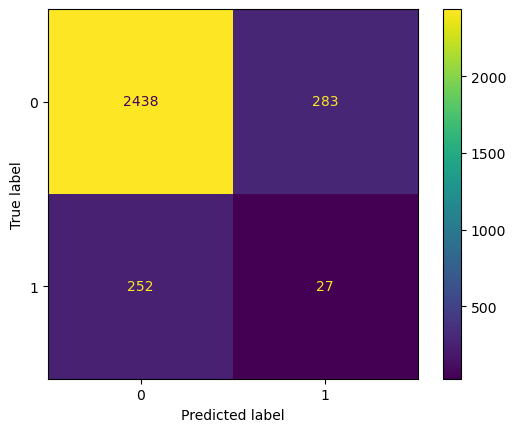

In [165]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


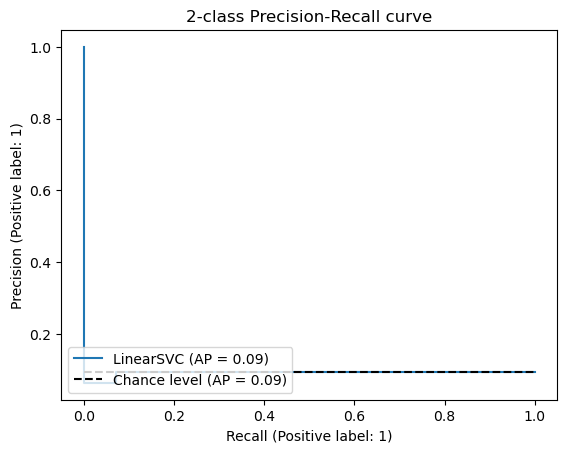

In [158]:
Y_scores = model_dtc.predict_proba(X_test)[:, 1]
display = PrecisionRecallDisplay.from_predictions(
    Y_test, Y_scores, name="LinearSVC", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

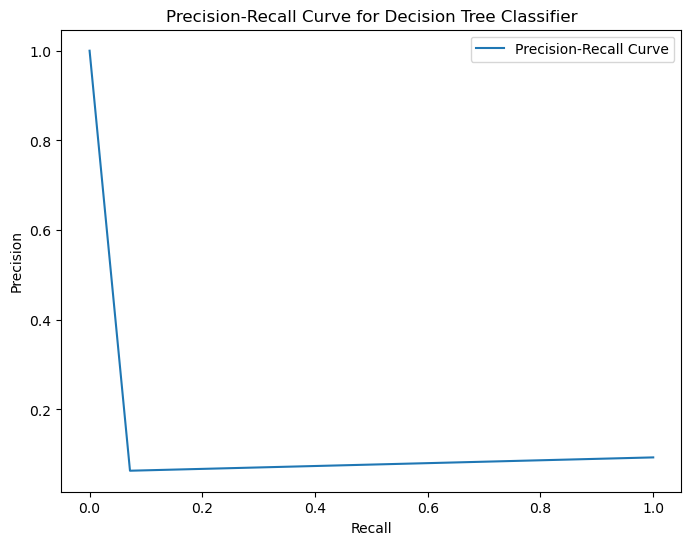

In [159]:
precision, recall, _ = precision_recall_curve(Y_test, Y_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Decision Tree Classifier')
plt.legend()
plt.show()

In [14]:
scores = cross_val_score(model_dtc, X, Y, cv=5)

In [15]:
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.8215 0.8195 0.8255 0.811  0.8205]
Mean cross-validation score: 0.8196


### Nearest Neighbors:

In [166]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn = model_knn.fit(X_train, Y_train)
X_test_knn = np.array(X_test)
Y_pred_knn = model_knn.predict(X_test_knn) 
print("MSE: \n" + str(np.round(mean_squared_error(Y_test, Y_pred_knn), 4)))
acc_knn = accuracy_score(Y_test, Y_pred_knn)
print("Accuracy Score: \n" + str(acc_knn))
f1 = np.round(f1_score(Y_test, Y_pred_knn, average='weighted'), 4)
print("F1 Score: \n" + str(f1))

MSE: 
0.115
Accuracy Score: 
0.885
F1 Score: 
0.8547


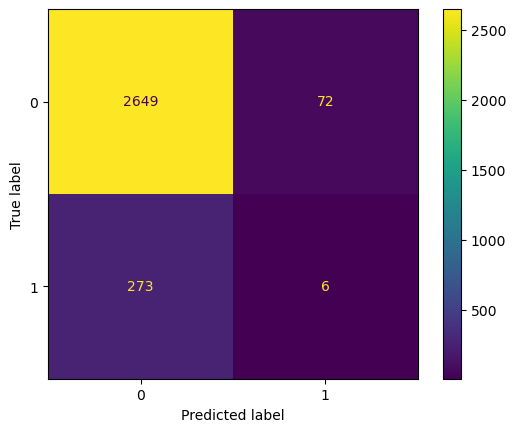

In [167]:
cm_knn = confusion_matrix(Y_test, Y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()

### Stochastic Gradient Descent learning algorithm (SGD):

In [162]:
model_sgd = SGDClassifier()
model_sgd = model_sgd.fit(X_train, Y_train)
Y_pred_sgd = model_sgd.predict(X_test)
print("MSE: \n" + str(np.round(mean_squared_error(Y_test, Y_pred_sgd), 4)))
acc_sgd = np.round(accuracy_score(Y_test, Y_pred_sgd), 4)
print("Accuracy Score: \n" + str(acc_sgd))
f1_sgd = np.round(f1_score(Y_test, Y_pred_sgd, average='weighted'), 4)
print("F1 Score: \n" + str(f1_sgd))

MSE: 
0.098
Accuracy Score: 
0.902
F1 Score: 
0.8603


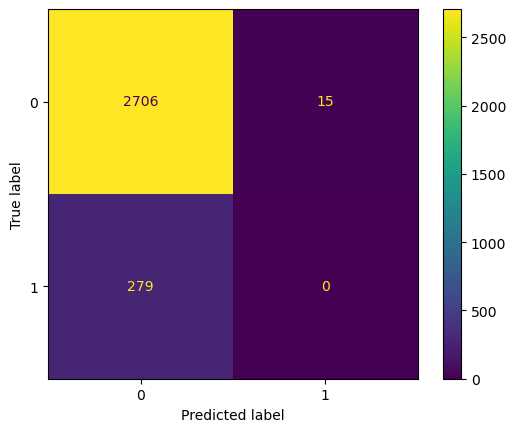

In [163]:
cm_sgd = confusion_matrix(Y_test, Y_pred_sgd)
disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd)
disp_sgd.plot()

### Pitfalls and performance analysis of our models:
Decision Tree Classifier:
- Drawback: classification at each step only use ’local’ information
- Overfitting can be reduced by Cost complexity pruning: adding a cost to leafy tree. Not implemented in SKLearn library.


Stockastic Gradiant Descent: 
- We could be getting to a local minimum in our descent and not a global minimum.
- When looking at its performance, we can see that this model does a very bad job at predicting the actual defaults, which is our main goal and just ends up sticking to the most probable scenario which is to predict a non-default. That is why, when looking at our confusion matrix, we see that it predicts correctly almost all of the non-default and close to 0 of the actual default loans.

# Feature Selection (35 points)
*10 points for correct code*

*15 points for correct reasoning and interpretation*

*10 points for explanation pitfalls*

Now that we've compared the performance of the different models, we place our judgement upon 
the dimensionality of the data. The dimension reduction methods discussed so far are 
L2 regularization and LASSO. Combining these methods gives us the Elastic Net method. What are some pitfalls of L2 regularization and of LASSO? How does Elastic Net overcome these pitfalls?

The Elastic Net method uses two parameters, l1_ratio and α. l1_ratio takes on a value between 0 and 1, and α a value higher than 0. Use the Elastic Net method to get an impression of the importance of the features, and make 
an appropriate and argumented decision regarding their individual inclusion.

• Limitation of Ridge Regression
- Ridge regression decreases the complexity of a model but does not reduce the number of
variables since it never leads to a coefficient been zero rather only minimizes it. Hence,
this model is not good for feature reduction.

• Limitation of Lasso Regression
- If there are two or more highly collinear variables then LASSO regression select one of
them randomly which is not good for the interpretation of data
- Lasso sometimes struggles with some types of data. If the number of predictors (p) is
greater than the number of observations (n), Lasso will pick at most n predictors as
non-zero, even if all predictors are relevant (or may be used in the test set).
Solution: weigh Ridge and Lasso → Elastic Net


In [153]:
elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.1)
elastic_net.fit(X, Y)

ElasticNet(alpha=0.01, l1_ratio=0.1)

In [154]:
feature_importance = pd.DataFrame()
feature_importance['Features'] = X.columns
feature_importance['Elastic Net Coefficients'] = elastic_net.coef_
feature_importance = feature_importance.sort_values(by = 'Elastic Net Coefficients', key=abs, ascending = False)
for i, j in feature_importance.iterrows():
    print (j['Features'] +': ' + str(np.round(j['Elastic Net Coefficients'], 4)))


Grade_C: 0.0055
Total Collection Amount: 0.0052
Initial List Status_f: 0.0051
Initial List Status_w: -0.0051
Loan Title_Debt consolidation: -0.0049
Debit to Income: -0.0047
Total Received Late Fee: 0.0041
Revolving Utilities: -0.0038
Inquires - six months: -0.0034
Verification Status_Source Verified: 0.0032
Total Accounts: -0.0029
Total Revolving Credit Limit: 0.0026
Total Current Balance: 0.0024
Employment Duration_OWN: 0.002
Delinquency - two years: 0.0018
Loan Amount: -0.0017
Funded Amount Investor: -0.0016
Recoveries: -0.0015
Open Account: -0.0013
Collection Recovery Fee: -0.0013
Employment Duration_MORTGAGE: -0.0012
Interest Rate: -0.0008
Total Received Interest: -0.0005
Sub Grade_C1: -0.0002
Last week Pay: -0.0002
Loan Title_personal: 0.0
Loan Title_debt loan: -0.0
Loan Title_get out of debt: 0.0
Loan Title_home improvement: -0.0
Loan Title_loan1: 0.0
Grade_F: -0.0
Loan Title_pay off bills: -0.0
Loan Title_payoff: 0.0
Sub Grade_G4: -0.0
Loan Title_debt consolidation: 0.0
Loan Tit

# Recommendation (10 points)
*10 points for paper*

Now that you've made an assessment of the key features and it is clear which model performs best, it is time to write a recommendation to Kiwibank. Explain what you have researched and present your results in a short paper in no more than 400 words. 

Focus on the bank's wants and needs, and minimize the technical talk. We recommend writing in LaTeX/Overleaf, but Word or another application is also fine. Hand the paper in as PDF, together with your Jupyter Notebook, in a ZIP-file.